# 03MIAR - Algoritmos de optimización
## Actividad guiada 2

*Lautaro Medrano*

## Presentación

Profesor:
- Grupos A2, A3, B1, B2: David Álvarez Robles (dalvarezr@professor.universidadviu.com)

## Objetivos
- Comprender la utilidad y aplicar algoritmos dinámicos
- Comprender la utilidad y aplicar algoritmos de ramificación y poda
- Comprender la utilidad y aplicar el algoritmo de optimización por descenso de gradiente

## Programación dinámica - Problema del viaje por el río
- Se divide el problema en subproblemas más pequeños para poder usar las soluciones más adelante
- Si el problema verifica el principio de optimalidad de Bellman "en una secuencia óptima de decisiones, toda sub-secuencia es también óptima" esto funciona bien
- Guardar soluciones parciales + recursividad = complejidad

In [1]:
import math

i = float("inf")

tarifas = [
    [0, 5, 4, 3, i, i, i],
    [i, 0, i, 2, 3, i, 11],
    [i, i, 0, 1, i, 4, 10],
    [i, i, i, 0, 5, 6, 9],
    [i, i, i, i, 0, i ,4],
    [i, i, i, i, i, 0, 3],
    [i, i, i, i, i, i, 0]
]

# Función para obtener precios finales entre dos nodos y qué rutas seguir
def obtener_precios_y_rutas(tarifas):
    # Inicialización de tabla de precios y rutas (precios a infinito como peor caso)
    nodos = len(tarifas[0])
    precios = [[i]*nodos for i in [float("inf")]*nodos]
    ruta = [[i]*nodos for i in [""]*nodos]

    # Recorremos todos los caminos (desde "n" hasta un "n" superior -> Ej: 0 a 1, 0 a 2, 1 a 4... pero nunca de 1 a 0 o de 4 a 2)
    for i in range(nodos-1):
        for j in range(i+1,nodos):

            # Asumimos que el mínimo es la tarifa de un nodo a otro inicialmente
            minimo = tarifas[i][j]
            # Asumimos que la mejor ruta de un nodo a otro comienza en el nodo inicial (ej: 0,1 -> 0, 0,4 -> 0, 2,5 -> 2)
            ruta[i][j] = i

            # Recorremos posibles movimientos intermedios
            for k in range(i,j):
                #print(precios)
                #print(f"i: {i}, j: {j}, k: {k}, precios_ik: {precios[i][k]}, tarifas_kj: {tarifas[k][j]}")
                # Si el precio de ir de i a k más la tarifa de k a j es menor que la tarifa de i a j, nos quedamos con esa ruta
                if (precios[i][k] + tarifas[k][j] < minimo):
                    minimo = precios[i][k] + tarifas[k][j]
                    ruta[i][j] = k
                # Actualizamos precio de i a j como el mínimo (puede ser pasando por k)
                precios[i][j] = minimo

    # Retornamos tabla de precios y de rutas de un nodo a otro
    return precios, ruta

# Función que calcula la ruta óptima a seguir
def calcular_ruta(ruta, inicio, fin, resultado = []):
    # Si el nodo inicial es igual al final, devolvemos el nodo
    if inicio == fin:
        #print(f"{inicio}")
        resultado.append(inicio)
        return resultado
    # Si tengo que desplazarme, calculo recursivamente la ruta de inicio a final siguiendo la tabla de rutas
    else:
        #print(f"{fin}")
        resultado.append(fin)
        return calcular_ruta(ruta, inicio, ruta[inicio][fin])

precios, ruta = obtener_precios_y_rutas(tarifas)

for fila in precios:
  print(fila)
print("---")
for fila in ruta:
  print(fila)

desde=0
hasta=6
resultado = calcular_ruta(ruta, desde, hasta)
print("---")
print(f"Ruta a seguir: {resultado[::-1]}")

[inf, 5, 4, 3, 8, 8, 11]
[inf, inf, inf, 2, 3, 8, 7]
[inf, inf, inf, 1, 6, 4, 7]
[inf, inf, inf, inf, 5, 6, 9]
[inf, inf, inf, inf, inf, inf, 4]
[inf, inf, inf, inf, inf, inf, 3]
[inf, inf, inf, inf, inf, inf, inf]
---
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']
---
Ruta a seguir: [0, 2, 5, 6]


## Ramificación y poda - Problema de las tareas
- Se necesitan funciones auxiliares para calcular todo el grafo (árbol)
- Función para calcular costes de soluciones parciales (no completas)
- Función para calcular cota inferior (muy optimista, repitiendo tareas si es necesario aunque la poda sea peor)
- Función para crear hijos e ir construyendo las soluciones
- Función para ramificar nodos y podar

In [2]:
import itertools
import math

costes = [
    [11,12,18,40],
    [14,15,13,22],
    [11,17,19,23],
    [17,14,20,28]
]

#for s in itertools.permutations(range(len(costes))):
#  print(s)

In [3]:
def fuerza_bruta(costes):

    optimo = float("inf")

    for s in itertools.permutations(range(len(costes))):
        coste = sum(costes[i][s[i]] for i in range(len(costes))) # Acumulo costes de cada agente
        if (coste < optimo):
            tareas, optimo = s, coste

    return tareas, optimo

tareas, optimo = fuerza_bruta(costes)
print(f"Obtenida mejor solución {tareas} con coste {optimo} por fuerza bruta")

Obtenida mejor solución (0, 2, 3, 1) con coste 61 por fuerza bruta


In [4]:
def coste_parcial(solucion, costes):
    coste = 0

    for i in range(len(solucion)):
        coste += costes[i][solucion[i]]

    return coste

#coste = coste_parcial((0,1),costes) # 11 + 15 = 26
#print(coste)

In [5]:
def cota_inferior(solucion, costes):
    # Calculo el coste parcial de la solución dada
    coste = coste_parcial(solucion,costes)

    # Calculo coste mínimo de opciones restantes no usadas permitiendo reutilización por sencillez (relajación = menos poda)
    no_usadas = set(range(len(costes)))-set(solucion)

    for i in range(len(solucion),len(costes)):
        coste += min([costes[i][j] for j in no_usadas])

    return coste

#CI = cota_inferior((0,1),costes)
#print(CI)

In [6]:
# def cota_superior(solucion, costes):
#     # Calculo el coste parcial de la solución dada
#     coste = coste_parcial(solucion,costes)

#     # Calculo coste máximo de opciones restantes no usadas
#     no_usadas = set(range(len(costes)))-set(solucion)

#     for i in range(len(solucion),len(costes)):
#         coste += max([costes[i][j] for j in no_usadas])

#     return coste

# CS = cota_superior((0,1),costes)
# print(CS)

In [7]:
# Función para crear las ramas del árbol
def crear_hijos(solucion, dimension):
  hijos = []
  for i in range(dimension):
    if i not in solucion:
      hijos.append({'s':solucion + (i,)})
  return hijos

#crear_hijos((0,1),4)

In [8]:
def ramificacion_y_poda(costes):

    dimension = len(costes)

    # Inicializo solución a vacío con el peor coste posible
    mejor_solucion = tuple(i for i in range(dimension))
    mejor_coste = coste_parcial(mejor_solucion,costes)

    # Creo un array de nodos y lo inicializo con una solución vacía (para comenzar por algo)
    nodos = []
    nodos.append({'s':(), 'ci':cota_inferior((),costes)})

    # Llevo cuenta de iteraciones por debugging
    iteracion = 0

    # Mientras haya nodos por explorar, aplico ramificación y poda
    while(nodos):
        # Cojo el nodo más prometedor (menor cota inferior, aunque esto luego puede ser "peor" a posteriori)
        nodo = min(nodos, key=lambda x: x['ci'])

        # Ramifico el nodo para obtener sus hijos
        hijos = crear_hijos(nodo['s'],dimension)

        # Para cada hijo, hago el procesamiento adecuado antes de decidir si es solución completa o un nuevo nodo
        for hijo in hijos:

            # Si la dimensión de la solución es igual a la dimensión de costes, es una solución final
            if (len(hijo['s']) == dimension):
                # Calculo el coste de la solución obtenida en el árbol
                coste = coste_parcial(hijo['s'],costes)
                # Si el coste es mejor, me lo quedo como solución
                if (coste < mejor_coste):
                    mejor_solucion = hijo['s']
                    mejor_coste = coste

            # Si la dimensión de la solución no es igual a la dimensión de costes, aplico poda
            else:
                # Calculo cota inferior del hijo
                cota_inferior_hijo = cota_inferior(hijo['s'], costes)
                # Si la cota inferior es menor que el mejor coste, lo añado a la lista de nodos a actualizar
                # Si la cota inferior fuera mayor, no tiene sentido porque no puede mejorar mi solución -> Poda
                if (cota_inferior_hijo <= mejor_coste):
                    nodos.append({'s':hijo['s'], 'ci':cota_inferior_hijo})
                #else:
                    #print(mejor_coste)
                    #print(f"Nodo eliminado: {hijo['s']} con cota inferior {cota_inferior_hijo}")

        # Elimino el nodo ya mirado
        nodos.remove(nodo)

        # Llevo la cuenta de las iteraciones que hago
        iteracion += 1

    return iteracion, mejor_solucion, mejor_coste

iteraciones, mejor_solucion, mejor_coste = ramificacion_y_poda(costes)
print(f"Obtenida mejor solución {mejor_solucion} con coste {mejor_coste} en {iteraciones} iteraciones")

Obtenida mejor solución (0, 2, 3, 1) con coste 61 en 17 iteraciones


## Descenso del gradiente - Optimización de funciones
- Se lleva a cabo una optimización basada en el método del descenso de gradiente
- Se calcula el vector de derivadas parciales y se minimiza la función objetivo actualizando los nuevos puntos (ver figura)

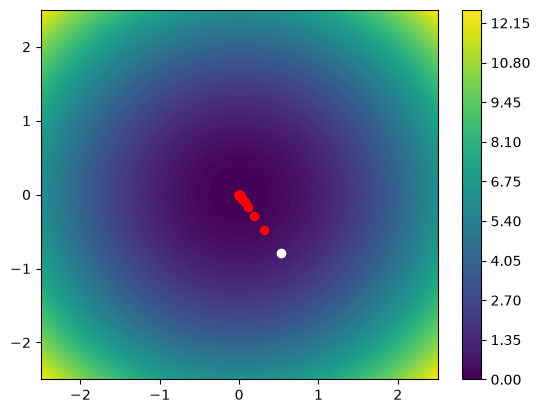

In [9]:
import math
import matplotlib.pyplot as plt
import numpy as np
import random

f = lambda X : X[0]**2 + X[1]**2 # x^2 + y^2
df = lambda X : [2*X[0] , 2*X[1]] # (2x, 2y)

resolucion = 100
rango = 2.5
X = np.linspace(-rango, rango, resolucion)
Y = np.linspace(-rango, rango, resolucion)
Z = np.zeros([resolucion, resolucion])

for ix, x in enumerate(X):
    for iy, y in enumerate(Y):
        Z[ix,iy] = f([x,y])

plt.contourf(X, Y, Z, resolucion)
plt.colorbar()

P = [random.uniform(-2,2), random.uniform(-2,2)]
plt.plot(P[0],P[1],"o",c="white")

tasa_aprendizaje = 0.2
for _ in range(500):
    grad = df(P)
    P[0], P[1] = P[0] - tasa_aprendizaje*grad[0], P[1] - tasa_aprendizaje*grad[1]
    plt.plot(P[0],P[1],"o",c="red")

## Actividades extra
- Ramificación y poda
  - Generar matrices con valores aleatorios de mayores dimensiones (5,6,7,…) y ejecutar ambos algoritmos.
  - ¿A partir de que dimensión el algoritmo por fuerza bruta deja de ser una opción?
  - ¿Hay algún valor de la dimensión a partir de la cual el algoritmo de ramificación y poda también deja de ser una opción válida?

- Descenso de gradiente
  - Minimizar la función sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - E^y)

### Matrices con valores aleatorios

De 5 a 12 dimensiones.

In [10]:
import random

def generate_random_matrix(n):
    matrix = []

    for i in range(n):
        matrix.append([])
        for j in range(n):
            if i == j:
                matrix[i].append(0)
            elif i > j:
                matrix[i].append(random.randint(0, 10))
            else:
                matrix[i].append(float("inf"))

    return matrix

for i in range(5,12):
    matrix = generate_random_matrix(i)

    print(f"=== Fuerza bruta (n = {i}) ===")
    %time fuerza_bruta(matrix)

    print(f"=== Ramificación y poda (n = {i}) ===")
    %time ramificacion_y_poda(matrix)

    print()

=== Fuerza bruta (n = 5) ===
CPU times: user 54 μs, sys: 0 ns, total: 54 μs
Wall time: 56 μs
=== Ramificación y poda (n = 5) ===
CPU times: user 35 μs, sys: 9 μs, total: 44 μs
Wall time: 43.9 μs

=== Fuerza bruta (n = 6) ===
CPU times: user 346 μs, sys: 8 μs, total: 354 μs
Wall time: 354 μs
=== Ramificación y poda (n = 6) ===
CPU times: user 52 μs, sys: 4 μs, total: 56 μs
Wall time: 57.9 μs

=== Fuerza bruta (n = 7) ===
CPU times: user 2.54 ms, sys: 11 μs, total: 2.55 ms
Wall time: 2.56 ms
=== Ramificación y poda (n = 7) ===
CPU times: user 79 μs, sys: 0 ns, total: 79 μs
Wall time: 79.9 μs

=== Fuerza bruta (n = 8) ===
CPU times: user 19.1 ms, sys: 471 μs, total: 19.5 ms
Wall time: 19.2 ms
=== Ramificación y poda (n = 8) ===
CPU times: user 84 μs, sys: 0 ns, total: 84 μs
Wall time: 84.9 μs

=== Fuerza bruta (n = 9) ===
CPU times: user 183 ms, sys: 1.52 ms, total: 185 ms
Wall time: 184 ms
=== Ramificación y poda (n = 9) ===
CPU times: user 119 μs, sys: 1 μs, total: 120 μs
Wall time: 120

Para el caso de **fuerza bruta** vemos que ya en n = 11 el algoritmo empieza a tomar tiempos que no son aceptables, por ejemplo, para una aplicación web. Una ejecución para n = 12 ya tarda varios minutos.

In [11]:
for i in range(20, 360, 30):
    matrix = generate_random_matrix(i)

    print(f"=== Ramificación y poda (n = {i}) ===")
    %time ramificacion_y_poda(matrix)

=== Ramificación y poda (n = 20) ===
CPU times: user 1.67 ms, sys: 0 ns, total: 1.67 ms
Wall time: 1.67 ms
=== Ramificación y poda (n = 50) ===
CPU times: user 43.5 ms, sys: 1.1 ms, total: 44.6 ms
Wall time: 43.8 ms
=== Ramificación y poda (n = 80) ===
CPU times: user 269 ms, sys: 1.44 ms, total: 270 ms
Wall time: 270 ms
=== Ramificación y poda (n = 110) ===
CPU times: user 945 ms, sys: 2.14 ms, total: 947 ms
Wall time: 947 ms
=== Ramificación y poda (n = 140) ===
CPU times: user 2.48 s, sys: 7.82 ms, total: 2.49 s
Wall time: 2.49 s
=== Ramificación y poda (n = 170) ===
CPU times: user 5.34 s, sys: 25.3 ms, total: 5.37 s
Wall time: 5.37 s
=== Ramificación y poda (n = 200) ===
CPU times: user 9.99 s, sys: 37.6 ms, total: 10 s
Wall time: 10 s
=== Ramificación y poda (n = 230) ===
CPU times: user 17.2 s, sys: 52.5 ms, total: 17.2 s
Wall time: 17.2 s
=== Ramificación y poda (n = 260) ===
CPU times: user 28.3 s, sys: 71.5 ms, total: 28.4 s
Wall time: 28.4 s
=== Ramificación y poda (n = 290)

Para el caso de **ramificación y poda** se puede ver que con un n = 320 el tiempo de procesado ya está por encima de un minuto. En este algoritmo vemos que el incremento de tiempo al aumentar n es muy inferior al de fuerza bruta, pero también posee un límite cercano a los valores probados que ya se vuelve incómodo para procesar.

### Optimización de la función $\sin\left(\frac{1}{2}x^2 - \frac{1}{4}y^2 + 3\right) \cos\left(2x + 1 - e^y\right)$

Para la optimización de la función utilizaremos el método de diferencias finitas centrales.

In [80]:
import numpy as np

h = 1e-5

def f(x, y):
    return np.sin(0.5 * x**2 - 0.25 * y**2 + 3) * np.cos(2 * x + 1 - np.exp(y))

def gradient_estimation(f, x, y):
    df_dx = (f(x + h, y) - f(x - h, y)) / (2 * h)
    df_dy = (f(x, y + h) - f(x, y - h)) / (2 * h)

    return [df_dx, df_dy]

learning_rate = 0.1
max_iterations = 100

min_x, min_y = None, None
min_value = float("inf")

space = -2, 2
for i in range(10):
    x = random.randint(*space)
    y = random.randint(*space)

    for i in range(max_iterations):
        gradient = gradient_estimation(f, x, y)

        x -= learning_rate * gradient[0]
        y -= learning_rate * gradient[1]

    f_x_y = f(x, y)

    if f_x_y < min_value:
        min_x, min_y = x, y
        min_value = f_x_y

print(f"El valor mínimo encontrado de la función es: {min_value}")
print(f"Y se encuentra en: {round(min_x, 2)}, {round(min_y, 2)}")


El valor mínimo encontrado de la función es: -1.0
Y se encuentra en: -2.03, 1.17


Para probar la función se realizan 10 iteraciones con x e y aleatorios en un rango de -2 a 2 y se toma el menor valor encontrado por todas esas iteraciones

### Fuentes utilizadas

- https://es.wikipedia.org/wiki/Diferencia_finita